In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings


In [44]:
car_dataset = pd.read_csv('carprediction_data.csv')

In [46]:
car_dataset.head()

,CAR_NAME,YEAR,SELLING_PRICE,PRESENT_PRICE,KMS_DRIVEN,FUEL_TYPE,SELLER_TYPE,TRANSMISSION,OWNER
0,TATA NEXON,2020,"9,20,000","11,80,000","18,000",PETROL,DEALER,MANUAL,FIRST
1,MAHINDRA SCORPIO,2014,"9,00,000","13,50,000","70,000",DIESEL,INDIVIDUAL,MANUAL,SECOND
2,HONDA CITY,2015,"7,20,000","10,50,000","45,000",PETROL,INDIVIDUAL,MANUAL,FIRST
3,TOYOTA FORTUNER,2016,"21,00,000","27,00,000","55,000",DIESEL,DEALER,AUTOMATIC,SECOND
4,HONDA AMAZE,2017,"4,80,000","6,90,000","42,000",PETROL,INDIVIDUAL,MANUAL,FIRST


In [12]:
car_dataset.shape

(10, 10)

In [47]:
car_dataset.describe()

,YEAR
count,10.000000
mean,2018.800000
std,3.614784
min,2014.000000
25%,2016.250000
50%,2018.500000
75%,2020.000000
max,2025.000000


In [51]:
print("\nFuel Type:")
print(car_dataset['FUEL_TYPE'].value_counts())

print("\nSeller Type:")
print(car_dataset['SELLER_TYPE'].value_counts())

print("\nTransmission:")
print(car_dataset['TRANSMISSION'].value_counts())

print("\nOwner:")
print(car_dataset['OWNER'].value_counts())


Fuel Type:
FUEL_TYPE
PETROL    7
DIESEL    3
Name: count, dtype: int64

Seller Type:
SELLER_TYPE
DEALER        6
INDIVIDUAL    4
Name: count, dtype: int64

Transmission:
TRANSMISSION
MANUAL       6
AUTOMATIC    4
Name: count, dtype: int64

Owner:
OWNER
FIRST      8
SECOND     2
Name: count, dtype: int64


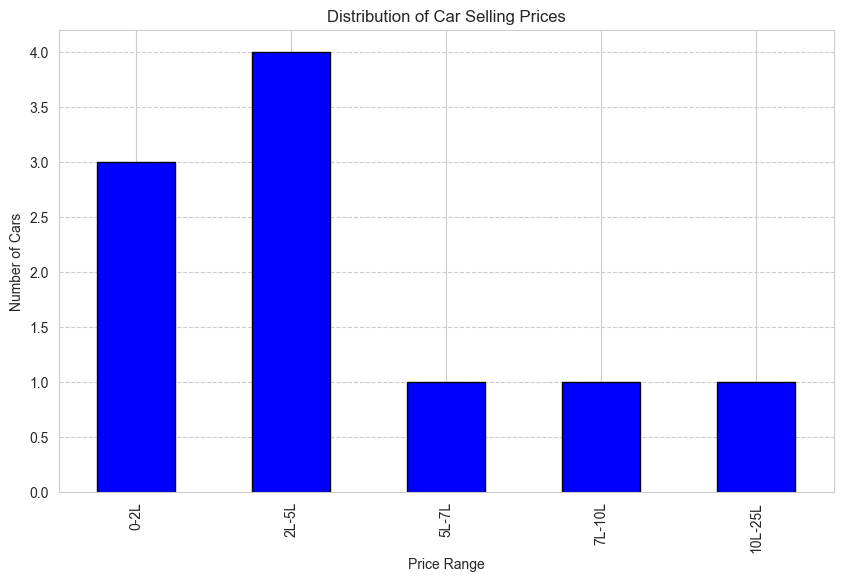

In [ ]:
plt.figure(figsize=(10,6))
price_count.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Price Range')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')
plt.show()

Text(0, 0.5, 'Selling Price (Lakhs)')

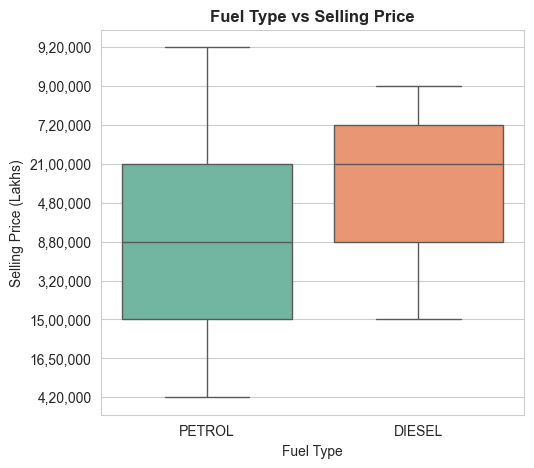

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='FUEL_TYPE', y='SELLING_PRICE', data=car_dataset, palette='Set2')
plt.title('Fuel Type vs Selling Price', fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (Lakhs)')

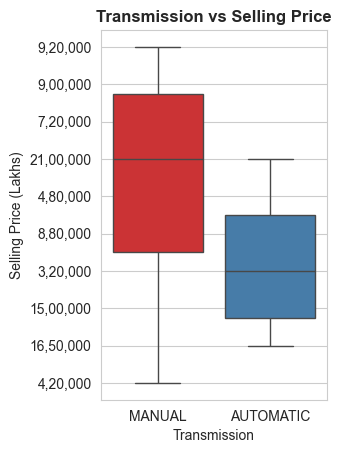

In [ ]:
plt.subplot(1,2,2)
sns.boxplot(x='TRANSMISSION', y='SELLING_PRICE', data=car_dataset, palette='Set1')
plt.title('Transmission vs Selling Price', fontweight='bold')
plt.xlabel('Transmission')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

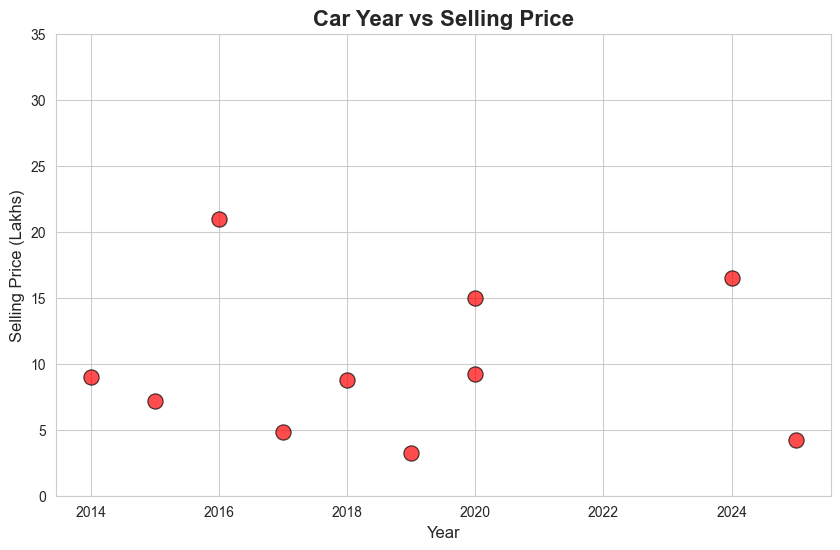

In [ ]:
car_dataset['SELLING_PRICE_L'] = car_dataset['SELLING_PRICE'].str.replace(',','').astype(float) / 100000
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")   
sns.scatterplot( x='YEAR',y='SELLING_PRICE_L', data=car_dataset,s=120,edgecolor='black',alpha=0.7
)
plt.title('Car Year vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Selling Price (Lakhs)', fontsize=12)
plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.show()

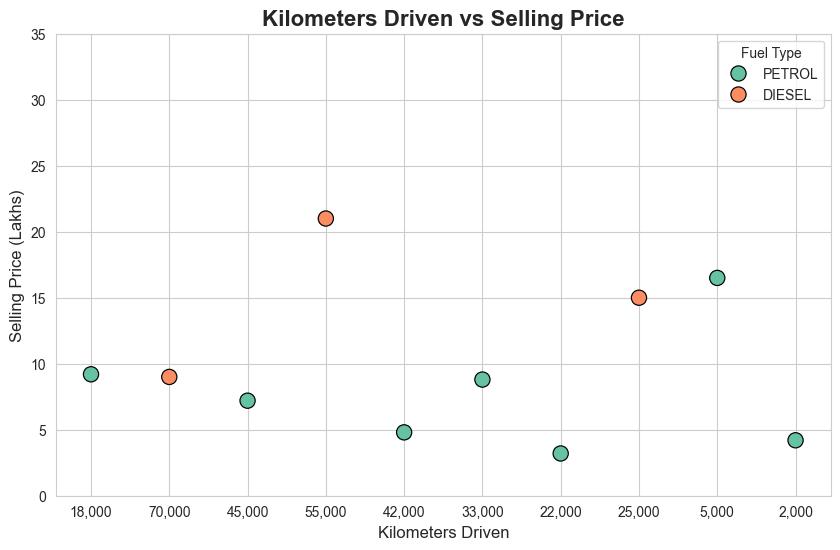

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert SELLING_PRICE to Lakhs
car_dataset['SELLING_PRICE_L'] = car_dataset['SELLING_PRICE'].str.replace(',','').astype(float) / 100000

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.scatterplot(
    x='KMS_DRIVEN',
    y='SELLING_PRICE_L',
    hue='FUEL_TYPE',
    data=car_dataset,
    s=120,          # size of points
    palette='Set2',
    edgecolor='black'
)

plt.title('Kilometers Driven vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Kilometers Driven', fontsize=12)
plt.ylabel('Selling Price (Lakhs)', fontsize=12)
plt.yticks([0,5,10,15,20,25,30,35])

plt.legend(title='Fuel Type')
plt.show()

In [ ]:
 
car_dataset.replace({'FUEL_TYPE': {'petrol':0, 'diesel':1}}, inplace=True)
car_dataset.replace({'SELLER_TYPE': {'dealer':0, 'individual':1}},inplace=True)
car_dataset.replace({'TRANSMISSION': {'manual':0, 'automatic':1}},inplace=True)
print("Encoded Dataset")
car_dataset.head() 

Encoded Dataset


,CAR_NAME,YEAR,SELLING_PRICE,PRESENT_PRICE,KMS_DRIVEN,FUEL_TYPE,SELLER_TYPE,TRANSMISSION,OWNER,SELLING_PRICE_L
0,TATA NEXON,2020,"9,20,000","11,80,000","18,000",0,0,0,FIRST,9.2
1,MAHINDRA SCORPIO,2014,"9,00,000","13,50,000","70,000",1,1,0,SECOND,9.0
2,HONDA CITY,2015,"7,20,000","10,50,000","45,000",0,1,0,FIRST,7.2
3,TOYOTA FORTUNER,2016,"21,00,000","27,00,000","55,000",1,0,1,SECOND,21.0
4,HONDA AMAZE,2017,"4,80,000","6,90,000","42,000",0,1,0,FIRST,4.8
